# 9.4.2 从平滑矩到动态参数更新

## 学习目标与先修知识

由平滑的二阶矩推导转移系数更新，避免把估计状态（state）当真值。

先修：第7.6章固定区间平滑与高斯二阶矩，9.4.1的EM下界解释。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

把平滑后的状态曲线当成无误差数据，再回归下一时刻，会遗漏哪些量？动态参数（parameter）学习需要整段观测（observation）的信息，但不能事后改写原来的实时预测记录。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

只有两个状态时，平滑均值[1,2]、方差（variance）[1,1]、相邻协方差（covariance）.5。比较只用均值与使用完整二阶矩的结果。

In [2]:
print("均值回归：",2/1)
print("完整矩更新：",(.5+1*2)/(1+1**2))

均值回归： 2.0
完整矩更新： 1.25


## 模型假设

无输入（input）标量状态模型（model）x[t+1]=a x[t]+w[t]，y[t]=x[t]+v[t]，过程与观测噪声为独立零均值高斯，已知Q=.2 U²、R=.4 U²。x₀~N(0,1 U²)，与所有噪声独立，初始分布（distribution）固定且不依赖a。只更新无量纲（dimensionless）转移系数a，不施加稳定约束；若要稳定约束或平稳初态，必须重新定义目标。

## 数学解释与推导

固定Q时完整数据log似然（likelihood）中与a有关的项为 $-\sum_{t=0}^{T-1}(x_{t+1}-ax_t)^2/(2Q)$。E步以旧参数对全部观测平滑，记mₜ、Vₜ和 $C_t=\operatorname{Cov}(x_{t+1},x_t\mid y_{0:T})$，则
$$E[x_t^2\mid y]=V_t+m_t^2,\qquad E[x_{t+1}x_t\mid y]=C_t+m_{t+1}m_t.$$
对a求导置零，若分母正，
$$a^{new}=\frac{\sum_t(C_t+m_{t+1}m_t)}{\sum_t(V_t+m_t^2)}.$$
仅用平滑均值相乘同时遗漏方差和交叉协方差。分母为0时更新不唯一，本节返回None。新a下的平均残差（residual）二阶矩也要含V和C；它在这里是检查量，Q 保持原值。

标量RTS增益（gain）为 $J_t=P_t^f a/P_{t+1}^{pred}$。由平滑条件关系 $x_t=m_t^f+J_t(x_{t+1}-m_{t+1}^{pred})+e_t$，其中eₜ与给定未来状态后的信息独立，可得相邻平滑协方差 $C_t=J_t V_{t+1}^s$。因此只保存平滑方差仍不足以学习转移系数，还需相邻协方差。

精确平滑加精确M步满足上一节的观测似然不下降逻辑。用滤波矩替代平滑矩、把初态改成依赖a却仍使用此式，或静默裁剪a，都会改变推导条件。有限样本无约束更新可能得到|a|>1，并不自动意味着程序错误或真实系统不稳定。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def scalar_smoother(observed,coefficient,process_variance,noise_variance,initial_mean,initial_variance):
    predicted=[];pred_vars=[];filtered=[];fvars=[]
    mean,var=initial_mean,initial_variance
    for t,y in enumerate(observed):
        if t:mean,var=coefficient*mean,coefficient**2*var+process_variance
        predicted.append(mean);pred_vars.append(var)
        gain=var/(var+noise_variance);mean+=gain*(y-mean);var*=1-gain
        filtered.append(mean);fvars.append(var)
    means=list(filtered);variances=list(fvars);lag=[0.]*(len(observed)-1)
    for t in range(len(observed)-2,-1,-1):
        gain=fvars[t]*coefficient/pred_vars[t+1]
        means[t]+=gain*(means[t+1]-predicted[t+1])
        variances[t]+=gain*gain*(variances[t+1]-pred_vars[t+1])
        lag[t]=gain*variances[t+1]
    return means,variances,lag


def state_mstep(means,variances,lag_covariances):
    denom=sum(v+m*m for m,v in zip(means[:-1],variances[:-1]))
    if denom==0:return None,None
    numerator=sum(lag_covariances[t]+means[t]*means[t+1] for t in range(len(lag_covariances)))
    coefficient=numerator/denom
    q=sum(variances[t+1]+means[t+1]**2-2*coefficient*(lag_covariances[t]+means[t]*means[t+1])+coefficient**2*(variances[t]+means[t]**2) for t in range(len(lag_covariances)))/len(lag_covariances)
    # Q is fixed in this lesson; q above is the expected residual for inspection.
    return coefficient,q


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)


def gaussian_log_likelihood(observed,coefficient,process_variance,noise_variance,initial_mean,initial_variance):
    mean,var=initial_mean,initial_variance;result=0.
    for t,y in enumerate(observed):
        if t:mean,var=coefficient*mean,coefficient**2*var+process_variance
        result+=normal_logpdf(y,mean,var+noise_variance)
        gain=var/(var+noise_variance);mean+=gain*(y-mean);var*=1-gain
    return result

## 对照实验

固定一组教学读数，运行12次精确平滑与参数更新，检查真实观测log似然。右图对比平滑均值与观测，带是逐时状态的±1个后验（posterior）标准差（standard deviation），不是未来读数区间。

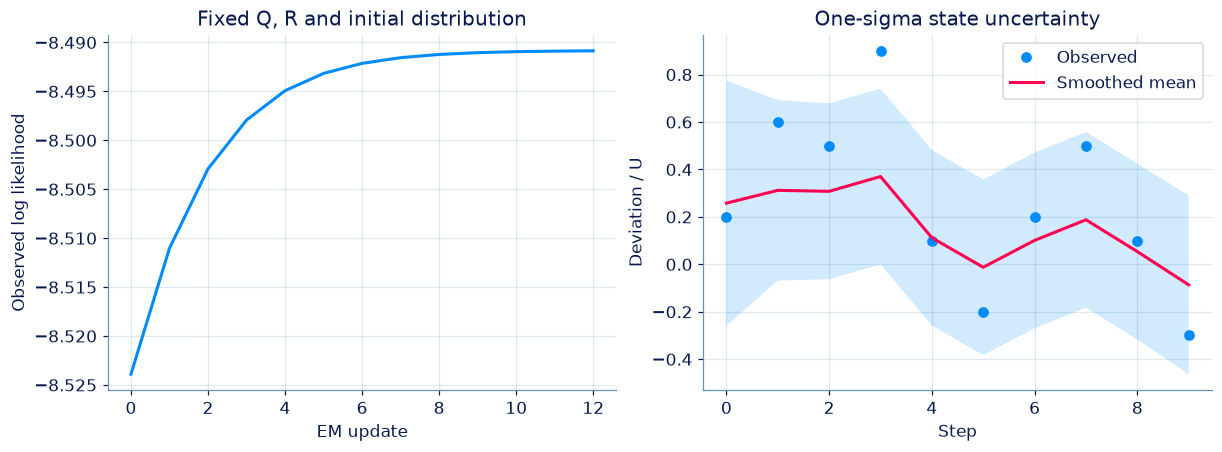

初始a、最终a、新a下残差二阶矩： 0.2 0.3731834954621415 0.15416059719858655


In [4]:
observed=[.2,.6,.5,.9,.1,-.2,.2,.5,.1,-.3];a=.2;trace=[];coefficients=[a]
for _ in range(12):
    trace.append(gaussian_log_likelihood(observed,a,.2,.4,0,1))
    sm,sv,cross=scalar_smoother(observed,a,.2,.4,0,1);a,residual=state_mstep(sm,sv,cross);coefficients.append(a)
trace.append(gaussian_log_likelihood(observed,a,.2,.4,0,1));sm,sv,cross=scalar_smoother(observed,a,.2,.4,0,1)
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(trace);axes[0].set(xlabel='EM update',ylabel='Observed log likelihood',title='Fixed Q, R and initial distribution')
t=np.arange(len(observed));axes[1].plot(t,observed,'o',label='Observed');axes[1].plot(t,sm,label='Smoothed mean');axes[1].fill_between(t,np.array(sm)-np.sqrt(sv),np.array(sm)+np.sqrt(sv),alpha=.18);axes[1].set(xlabel='Step',ylabel='Deviation / U',title='One-sigma state uncertainty');axes[1].legend();plt.show()
print('初始a、最终a、新a下残差二阶矩：',coefficients[0],coefficients[-1],residual)

## 结果解释

更新的是模型参数，平滑分布也随参数重新计算。训练似然随迭代变化，新观测上的预测则需另外检查。后验残差二阶矩反映当前平滑分布中的变化，它可以与固定的过程噪声（process noise）方差 Q 不同。若采用另一近似平滑器，应重新检查其目标与单调性。

### 独立核对

独立构造整段状态的联合高斯精度矩阵（matrix），直接求条件均值与协方差，核对平滑矩及相邻项，而不拿同一递推互相验证。

In [5]:
n=len(observed);precision=np.zeros((n,n));precision[0,0]=1
for t in range(n-1):
    precision[t,t]+=a*a/.2;precision[t+1,t+1]+=1/.2;precision[t,t+1]-=a/.2;precision[t+1,t]-=a/.2
precision+=np.eye(n)/.4;cov=np.linalg.inv(precision);mean=cov@(np.array(observed)/.4)
np.testing.assert_allclose(sm,mean,atol=1e-11);np.testing.assert_allclose(sv,np.diag(cov),atol=1e-11);np.testing.assert_allclose(cross,np.diag(cov,1),atol=1e-11)
assert min(np.diff(trace))>-1e-10
np.testing.assert_allclose(state_mstep([1,2],[1,1],[.5]),[1.25,1.875])
assert state_mstep([0,0],[0,1],[0])==(None,None)
print('整段联合高斯、相邻协方差、二阶矩和单调性通过。')

整段联合高斯、相邻协方差、二阶矩和单调性通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-04-隐变量与参数学习/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：用平滑矩更新转移系数

x[t+1]=a x[t]+w[t]，过程噪声（process noise）方差（variance）固定且为正。初始分布（distribution）与a无关。根据旧参数（parameter）下的平滑矩更新a，并检查残差（residual）二阶矩。

**函数与代码模板**

```python
def solve(
    means: list[float],
    variances: list[float],
    lag_covariances: list[float],
) -> tuple[float | None, float | None]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 同一次精确固定区间平滑得到的m0…mT。 | U |
| `variances` | `list[float]` | 对应的平滑方差V0…VT。 | U² |
| `lag_covariances` | `list[float]` | 第t项为Cov(x[t+1],x[t]&#124;全部观测（observation）)，共T项。 | U² |

**返回值**

按以下顺序返回元组：(coefficient, residual_second_moment)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficient` | <code>float &#124; None</code> | 无约束转移系数的一次M步更新。 | 1 |
| `residual_second_moment` | <code>float &#124; None</code> | 新系数下每步残差的后验（posterior）二阶矩平均。 | U² |

**计算规则**

D=sum(t=0…T−1)(Vt+mt²)，N=sum(Ct+m[t+1]mt)，a′=N/D。返回a′及mean(V[t+1]+m[t+1]²−2a′(Ct+m[t+1]mt)+a′²(Vt+mt²))；D=0时返回(None,None)。

**约束与边界**

- 2—50个状态（state）；输入（input）矩来自合法联合分布；方差非负；均值绝对值≤20；不把结果强制截断到稳定区间。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| means | 同一次精确固定区间平滑得到的m0…mT。 | [1.0, 2.0] | U |
| variances | 对应的平滑方差V0…VT。 | [1.0, 1.0] | U² |
| lag_covariances | 第t项为Cov(x[t+1],x[t]|全部观测（observation）)，共T项。 | [0.5] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
means = [1.0, 2.0]
variances = [1.0, 1.0]
lag_covariances = [0.5]

result = solve(means, variances, lag_covariances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficient | 无约束转移系数的一次M步更新。 | 1.25 | 1 |
| residual_second_moment | 新系数下每步残差的后验（posterior）二阶矩平均。 | 1.875 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.25, 1.875)
```

**样例解释**

D=2，N=2.5，a′=1.25；残差二阶矩为5−2×1.25×2.5+1.25²×2=1.875。仅用均值会错误得到2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用平滑矩更新转移系数](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-state-moments)

### 第 2 题 · 单项选择题：为什么不能只回归平滑均值

已知m_t=E[x_t|y]。用m[t+1]m[t]替代E[x[t+1]x[t]|y]遗漏什么？

- **A.** 相邻状态（state）的平滑交叉协方差（covariance）。
- **B.** 只遗漏可忽略的打印误差。
- **C.** 二者总相等。
- **D.** 只要有很多观测（observation）就可不检查地删除方差（variance）。

[作答：为什么不能只回归平滑均值](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-smoothing-products)

### 第 3 题 · 单项选择题：初始分布也依赖a

若采用平稳初态方差（variance）Q/(1−a²)，还能直接使用本节N/D更新吗？

- **A.** 能，初态总能忽略。
- **B.** 不能；初态对数密度也依赖a，目标及约束须重新推导。
- **C.** 只需删除首个读数。
- **D.** 把a改名便可消除依赖。

[作答：初始分布也依赖a](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-initial-parameter)

### 第 4 题 · 多项选择题：近似平滑代替精确E步

将精确平滑换成一个有偏近似，其他步骤照旧。哪些陈述合理？

- **A.** 原始观测（observation）似然（likelihood）的单调性不再自动保证。
- **B.** 应实际比较原似然或给出所用变分目标的保证。
- **C.** 名字仍叫EM就无需核验。
- **D.** 不同目标的上升不能混同。

[作答：近似平滑代替精确E步](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-approximate-e-step)

### 第 5 题 · 单项选择题：更新得到a大于1

一次无约束M步得到a=1.1。哪项正确？

- **A.** 计算必然错误。
- **B.** 有限记录的无约束最优可能不稳定；如需|a|<1须明确约束后重解。
- **C.** 静默裁剪到.99仍可声称原无约束精确M步。
- **D.** 这证明人体系统会永远增长。

[作答：更新得到a大于1](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-unstable-estimate)

**进一步阅读**

[Särkkä，Bayesian Filtering and Smoothing（2013开放版）](https://users.aalto.fi/~ssarkka/pub/cup_book_online_20131111.pdf)：第8章平滑、第12章参数估计；符号和数据按本教材重新组织。